# Ablation visualization: char-separated vs. direct prompting

Compares the char-separated zero-shot ablation against the direct (default-prompt) zero-shot baseline on the validation set.

Each model gets two bars (ablation vs. direct). Bar height encodes **WER**; a darker inner shade marks **DotER**. DotER is plotted nested inside WER for compactness — the two metrics use different denominators (words vs. ambiguous-Rasm characters), so they are independent percentages displayed on the same axis, not additive components.

In [12]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate


# Anchor paths to the project root so the notebook runs regardless of cwd.
def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / "setup.py").exists():
            return p
    raise RuntimeError("project root not found")


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())

In [13]:
ABLATION_DIR = PROJECT_ROOT / "tnqeet/dotting_models/llms/ablation_results/char_separated/val_dataset/zeroshot"
DIRECT_DIR = PROJECT_ROOT / "tnqeet/dotting_models/llms/evaluation_results/val_dataset/zeroshot/default_prompt"
FIGURES_DIR = PROJECT_ROOT / "tnqeet/dotting_models/llms/ablations/visualization_figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
def load_results(directory: Path, condition: str):
    rows = []
    for fname in sorted(os.listdir(directory)):
        if not fname.endswith(".json"):
            continue
        model = fname[: -len(".json")]
        with open(directory / fname, encoding="utf-8") as f:
            items = json.load(f)
        rows.append(
            {
                "model": model,
                "condition": condition,
                "WER": float(np.mean([r["wer"] for r in items])),
                "DotER": float(np.mean([r["doer"] for r in items])),
                "n_examples": len(items),
            }
        )
    return rows


ablation_rows = load_results(ABLATION_DIR, "char-separated (ablation)")
ablation_models = {r["model"] for r in ablation_rows}
direct_rows = [
    r for r in load_results(DIRECT_DIR, "direct (default)") if r["model"] in ablation_models
]

df = pd.DataFrame(ablation_rows + direct_rows)
df = df.sort_values(["model", "condition"]).reset_index(drop=True)
print(tabulate(df, headers="keys", tablefmt="grid", showindex=False, floatfmt=".4f"))

+--------------------------+---------------------------+--------+---------+--------------+
| model                    | condition                 |    WER |   DotER |   n_examples |
+==========================+===========================+========+=========+==============+
| claude-sonnet-4          | char-separated (ablation) | 0.2933 |  0.0818 |          120 |
+--------------------------+---------------------------+--------+---------+--------------+
| claude-sonnet-4          | direct (default)          | 0.2381 |  0.0832 |          120 |
+--------------------------+---------------------------+--------+---------+--------------+
| gemini-2.5-flash-preview | char-separated (ablation) | 0.4008 |  0.1205 |          120 |
+--------------------------+---------------------------+--------+---------+--------------+
| gemini-2.5-flash-preview | direct (default)          | 0.2225 |  0.0746 |          120 |
+--------------------------+---------------------------+--------+---------+--------------+

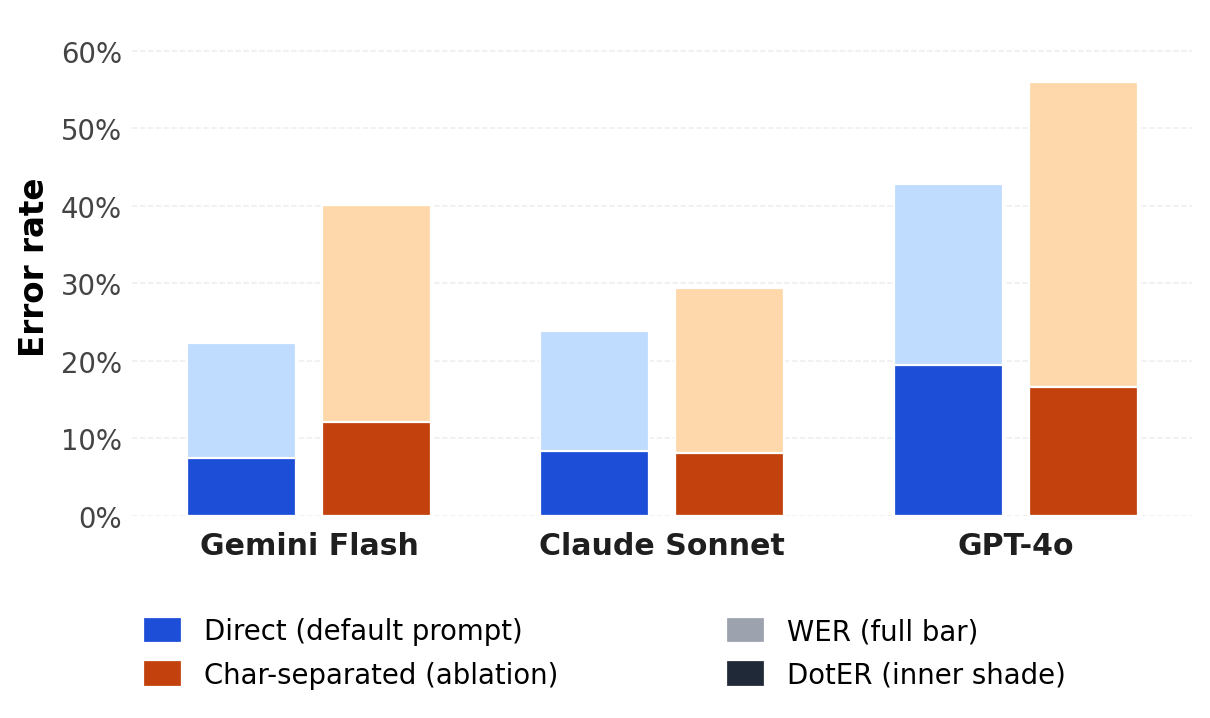

In [17]:
from io import BytesIO

from IPython.display import Image, display
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.labelweight": "bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Two condition hues; light = WER, dark = DotER (nested inside).
PALETTE = {
    "direct (default)":          {"wer": "#BFDBFE", "doer": "#1D4ED8"},  # blue
    "char-separated (ablation)": {"wer": "#FED7AA", "doer": "#C2410C"},  # warm orange
}

MODEL_DISPLAY = {
    "claude-sonnet-4":          "Claude Sonnet",
    "gemini-2.5-flash-preview": "Gemini Flash",
    "gpt-4o":                   "GPT-4o",
}


def plot_ablation_vs_direct(df, figsize=(7.6, 3.6), save_path=None):
    """Two bars per model (direct vs. ablation). Bar = WER, darker inner shade = DotER."""
    # Stable reading order: best direct-baseline WER first.
    models = (
        df[df["condition"] == "direct (default)"]
        .set_index("model")["WER"]
        .sort_values()
        .index.tolist()
    )
    conditions = ["direct (default)", "char-separated (ablation)"]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    group_spacing = 0.55  # slightly tighter than default (1.0)
    x = np.arange(len(models)) * group_spacing
    width = 0.17  # narrow bars

    for i, cond in enumerate(conditions):
        offset = (i - 0.5) * (width + 0.04)
        wers = [df[(df["model"] == m) & (df["condition"] == cond)]["WER"].iloc[0] for m in models]
        doters = [df[(df["model"] == m) & (df["condition"] == cond)]["DotER"].iloc[0] for m in models]

        # WER (light fill, full height).
        ax.bar(x + offset, wers, width,
               color=PALETTE[cond]["wer"], edgecolor="white", linewidth=0.9)
        # DotER (darker, nested inside WER).
        ax.bar(x + offset, doters, width,
               color=PALETTE[cond]["doer"], edgecolor="white", linewidth=0.9)

    # Axes and ticks
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in models])
    ax.set_xlim(x[0] - group_spacing / 2, x[-1] + group_spacing / 2)
    ax.set_ylabel("Error rate")
    ax.set_ylim(0, max(df["WER"]) * 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", length=0, pad=6)
    ax.tick_params(axis="y", length=0, pad=4, colors="#444444")
    for label in ax.get_xticklabels():
        label.set_color("#1F1F1F")
        label.set_fontweight(550)
    ax.grid(True, axis="y", alpha=0.22, linestyle="--", linewidth=0.6)
    ax.set_axisbelow(True)

    # Two legend groups, untitled, side by side.
    def _patch(face, label):
        return Patch(facecolor=face, edgecolor="white", linewidth=0.9, label=label)

    LEGEND_Y = -0.18
    leg_cond = ax.legend(
        handles=[
            _patch(PALETTE["direct (default)"]["doer"], "Direct (default prompt)"),
            _patch(PALETTE["char-separated (ablation)"]["doer"], "Char-separated (ablation)"),
        ],
        loc="upper left", bbox_to_anchor=(0.0, LEGEND_Y),
        ncol=1, frameon=False,
        handlelength=1.4, handleheight=1.1, labelspacing=0.55, borderaxespad=0.0,
    )
    leg_cond._legend_box.align = "left"
    ax.add_artist(leg_cond)

    leg_metric = ax.legend(
        handles=[
            _patch("#9CA3AF", "WER (full bar)"),
            _patch("#1F2937", "DotER (inner shade)"),
        ],
        loc="upper left", bbox_to_anchor=(0.55, LEGEND_Y),
        ncol=1, frameon=False,
        handlelength=1.4, handleheight=1.1, labelspacing=0.55, borderaxespad=0.0,
    )
    leg_metric._legend_box.align = "left"

    extras = (leg_cond, leg_metric)
    if save_path is not None:
        fig.savefig(save_path, format="pdf",
                    bbox_inches="tight", bbox_extra_artists=extras, pad_inches=0.10)

    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=180,
                bbox_inches="tight", bbox_extra_artists=extras, pad_inches=0.10)
    plt.close(fig)
    display(Image(buf.getvalue()))


plot_ablation_vs_direct(df, save_path=FIGURES_DIR / "llms_val_ablation_vs_direct.pdf")

In [16]:
# Per-model delta table: how much char-separation moves the metrics vs. the direct baseline.
pivot = df.pivot(index="model", columns="condition", values=["WER", "DotER"])
delta = pd.DataFrame(
    {
        "WER_direct": pivot[("WER", "direct (default)")],
        "WER_ablation": pivot[("WER", "char-separated (ablation)")],
        "WER_delta": pivot[("WER", "char-separated (ablation)")] - pivot[("WER", "direct (default)")],
        "DotER_direct": pivot[("DotER", "direct (default)")],
        "DotER_ablation": pivot[("DotER", "char-separated (ablation)")],
        "DotER_delta": pivot[("DotER", "char-separated (ablation)")] - pivot[("DotER", "direct (default)")],
    }
).sort_values("WER_direct")
print(tabulate(delta, headers="keys", tablefmt="grid", floatfmt="+.4f"))

+--------------------------+--------------+----------------+-------------+----------------+------------------+---------------+
| model                    |   WER_direct |   WER_ablation |   WER_delta |   DotER_direct |   DotER_ablation |   DotER_delta |
+==========================+==============+================+=============+================+==================+===============+
| gemini-2.5-flash-preview |      +0.2225 |        +0.4008 |     +0.1783 |        +0.0746 |          +0.1205 |       +0.0459 |
+--------------------------+--------------+----------------+-------------+----------------+------------------+---------------+
| claude-sonnet-4          |      +0.2381 |        +0.2933 |     +0.0552 |        +0.0832 |          +0.0818 |       -0.0014 |
+--------------------------+--------------+----------------+-------------+----------------+------------------+---------------+
| gpt-4o                   |      +0.4283 |        +0.5593 |     +0.1310 |        +0.1949 |          +0.1665 | 